# Category Trends Analysis — Dynamic Date Range
> Analisi category trends per periodo custom: **06-12 Aprile 2026**

In [14]:
import os, sys
from datetime import datetime, date, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

# Path setup
_PROJECT_ROOT = Path.cwd().parent
for _p in [str(_PROJECT_ROOT), str(_PROJECT_ROOT / 'reports')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

print("✓ Environment initialized")

✓ Environment initialized


## Configuration

In [15]:
# PARAMETRI — Modifica questi per analizzare periodi diversi
START_DATE = date(2026, 4, 6)
END_DATE = date(2026, 4, 12)
PROPERTY_ID = '394327334'
DOMAIN = 'https://taxidrivers.it'
GRANULARITY = 'Daily'  # Options: Daily, Weekly, Monthly

print(f"\n📊 CATEGORY TRENDS ANALYSIS")
print(f"{'='*70}")
print(f"Period: {START_DATE.strftime('%d/%m/%Y')} → {END_DATE.strftime('%d/%m/%Y')}")
print(f"Granularity: {GRANULARITY}")
print(f"Property ID: {PROPERTY_ID}")
print(f"{'='*70}")


📊 CATEGORY TRENDS ANALYSIS
Period: 06/04/2026 → 12/04/2026
Granularity: Daily
Property ID: 394327334


## Load Data from GA4

In [16]:
from ga4_api.ga4_api import Ga4Client
from etl.page_and_screen_etl import PageAndScreenETLFactory
from map_ga4_categories import map_ga4_categories

print("\n🔄 Loading data from GA4...")
ga4 = Ga4Client()

df = ga4.run_query(
    property_id=PROPERTY_ID,
    dimensions=['pagePath', 'date'],
    metrics=['screenPageViews', 'activeUsers', 'engagedSessions', 'sessions', 'averageSessionDuration'],
    start_date=START_DATE.strftime('%Y-%m-%d'),
    end_date=END_DATE.strftime('%Y-%m-%d')
)

print(f"✓ Loaded {len(df)} rows from GA4")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")


🔄 Loading data from GA4...
✓ Loaded 7071 rows from GA4
  Shape: (7071, 7)
  Columns: ['pagePath', 'date', 'screenPageViews', 'activeUsers', 'engagedSessions', 'sessions', 'averageSessionDuration']


## ETL Transformations

In [17]:
print("\n🔄 Applying ETL transformations...")

etl = PageAndScreenETLFactory.get_etl('en', df=df)
etl.apply_transformations()
df = etl.df

print(f"✓ After cleaning: {len(df)} rows")
print(f"  Null values: {df.isnull().sum().sum()}")


🔄 Applying ETL transformations...
Applying transformations...
Dropped 460 rows that did not end with '.html'.
Dropped 0 rows that were equal to '/'.
Transformations applied.
                                             pagePath      date  \
7   /88847/review/in-sala/dvdbluray/viaggio-cielo-...  20260412   
8   /524828/latest-news/anticipazioni/the-correcti...  20260406   
9   /525504/festival-di-cinema/cannes/selezione-uf...  20260409   
10  /525221/interviews/conversation/notte-prima-de...  20260409   
11  /524355/latest-news/si-fara/detective-hole-2-i...  20260406   

   screenPageViews activeUsers engagedSessions sessions averageSessionDuration  
7              168         151              78      162     101.98790274691358  
8              145         139              32      142     7.9537670915492962  
9               63          45              40       55     192.97765127272726  
10              62          55              17       58     88.140032431034484  
11              5

## Data Preparation & Categorization

In [18]:
# Parse date
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date_parsed'])

# Map categoria
print("\n🔄 Mapping categories...")
df['category'] = df['pagePath'].apply(map_ga4_categories)
print(f"✓ Found {df['category'].nunique()} categories")

# Convert metrics to numeric
for col in ['screenPageViews', 'activeUsers', 'engagedSessions', 'sessions', 'averageSessionDuration']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN metrics
df = df.dropna(subset=['screenPageViews', 'sessions'])

print(f"✓ Data ready: {len(df)} rows")
print(f"  Date range: {df['date_parsed'].min().date()} to {df['date_parsed'].max().date()}")


🔄 Mapping categories...
✓ Found 16 categories
✓ Data ready: 6611 rows
  Date range: 2026-04-06 to 2026-04-12


## Aggregation by Category & Time

In [19]:
print(f"\n🔄 Aggregating data (granularity: {GRANULARITY})...")

if GRANULARITY == 'Daily':
    agg_df = df.groupby(['category', 'date_parsed']).agg({
        'screenPageViews': 'sum',
        'activeUsers': 'sum',
        'engagedSessions': 'sum',
        'sessions': 'sum',
        'averageSessionDuration': 'mean'
    }).reset_index()
    time_label = 'Date'
elif GRANULARITY == 'Weekly':
    df['week'] = df['date_parsed'].dt.to_period('W').apply(lambda x: x.start_time)
    agg_df = df.groupby(['category', 'week']).agg({
        'screenPageViews': 'sum',
        'activeUsers': 'sum',
        'engagedSessions': 'sum',
        'sessions': 'sum',
        'averageSessionDuration': 'mean'
    }).reset_index()
    agg_df.rename(columns={'week': 'date_parsed'}, inplace=True)
    time_label = 'Week'
else:  # Monthly
    df['month'] = df['date_parsed'].dt.to_period('M').apply(lambda x: x.start_time)
    agg_df = df.groupby(['category', 'month']).agg({
        'screenPageViews': 'sum',
        'activeUsers': 'sum',
        'engagedSessions': 'sum',
        'sessions': 'sum',
        'averageSessionDuration': 'mean'
    }).reset_index()
    agg_df.rename(columns={'month': 'date_parsed'}, inplace=True)
    time_label = 'Month'

# Calculate engagement rate
agg_df['engagementRate'] = (agg_df['engagedSessions'] / agg_df['sessions'] * 100).round(2)

print(f"✓ Aggregated data:")
print(f"  Shape: {agg_df.shape}")
print(f"  Categories: {agg_df['category'].nunique()}")
print(f"  Time periods: {agg_df['date_parsed'].nunique()}")


🔄 Aggregating data (granularity: Daily)...
✓ Aggregated data:
  Shape: (111, 8)
  Categories: 16
  Time periods: 7


## Basic Statistics

In [20]:
print("\n📊 BASIC STATISTICS")
print(f"{'='*70}")

print(f"\n📈 Page Views per Category (TOTAL):")
pv_by_cat = agg_df.groupby('category')['screenPageViews'].sum().sort_values(ascending=False).head(15)
print(pv_by_cat)

print(f"\n👥 Active Users per Category:")
au_by_cat = agg_df.groupby('category')['activeUsers'].sum().sort_values(ascending=False).head(15)
print(au_by_cat)

print(f"\n💬 Average Engagement Rate per Category:")
er_by_cat = agg_df.groupby('category')['engagementRate'].mean().sort_values(ascending=False).head(15)
print(er_by_cat)

print(f"\n⏱  Average Session Duration per Category:")
asd_by_cat = agg_df.groupby('category')['averageSessionDuration'].mean().sort_values(ascending=False).head(15)
print(asd_by_cat)


📊 BASIC STATISTICS

📈 Page Views per Category (TOTAL):
category
News                        2479
Si farà                     2304
Speciali e Magazine         1806
Live Streaming On Demand    1704
Serie TV                    1470
Festival di Cinema           923
Anticipazioni                901
Recensioni                   589
Recensioni / In Sala         585
Trailers                     518
Interviste                   506
Altro                        278
Rubriche                     278
Guide e Film da Vedere       218
Cult Movies                  147
Name: screenPageViews, dtype: int64

👥 Active Users per Category:
category
News                        2157
Si farà                     1969
Speciali e Magazine         1550
Live Streaming On Demand    1509
Serie TV                    1263
Anticipazioni                803
Festival di Cinema           780
Recensioni                   504
Recensioni / In Sala         495
Trailers                     466
Interviste                   412
Ru

## Visualization 1: Page Views Trend by Category

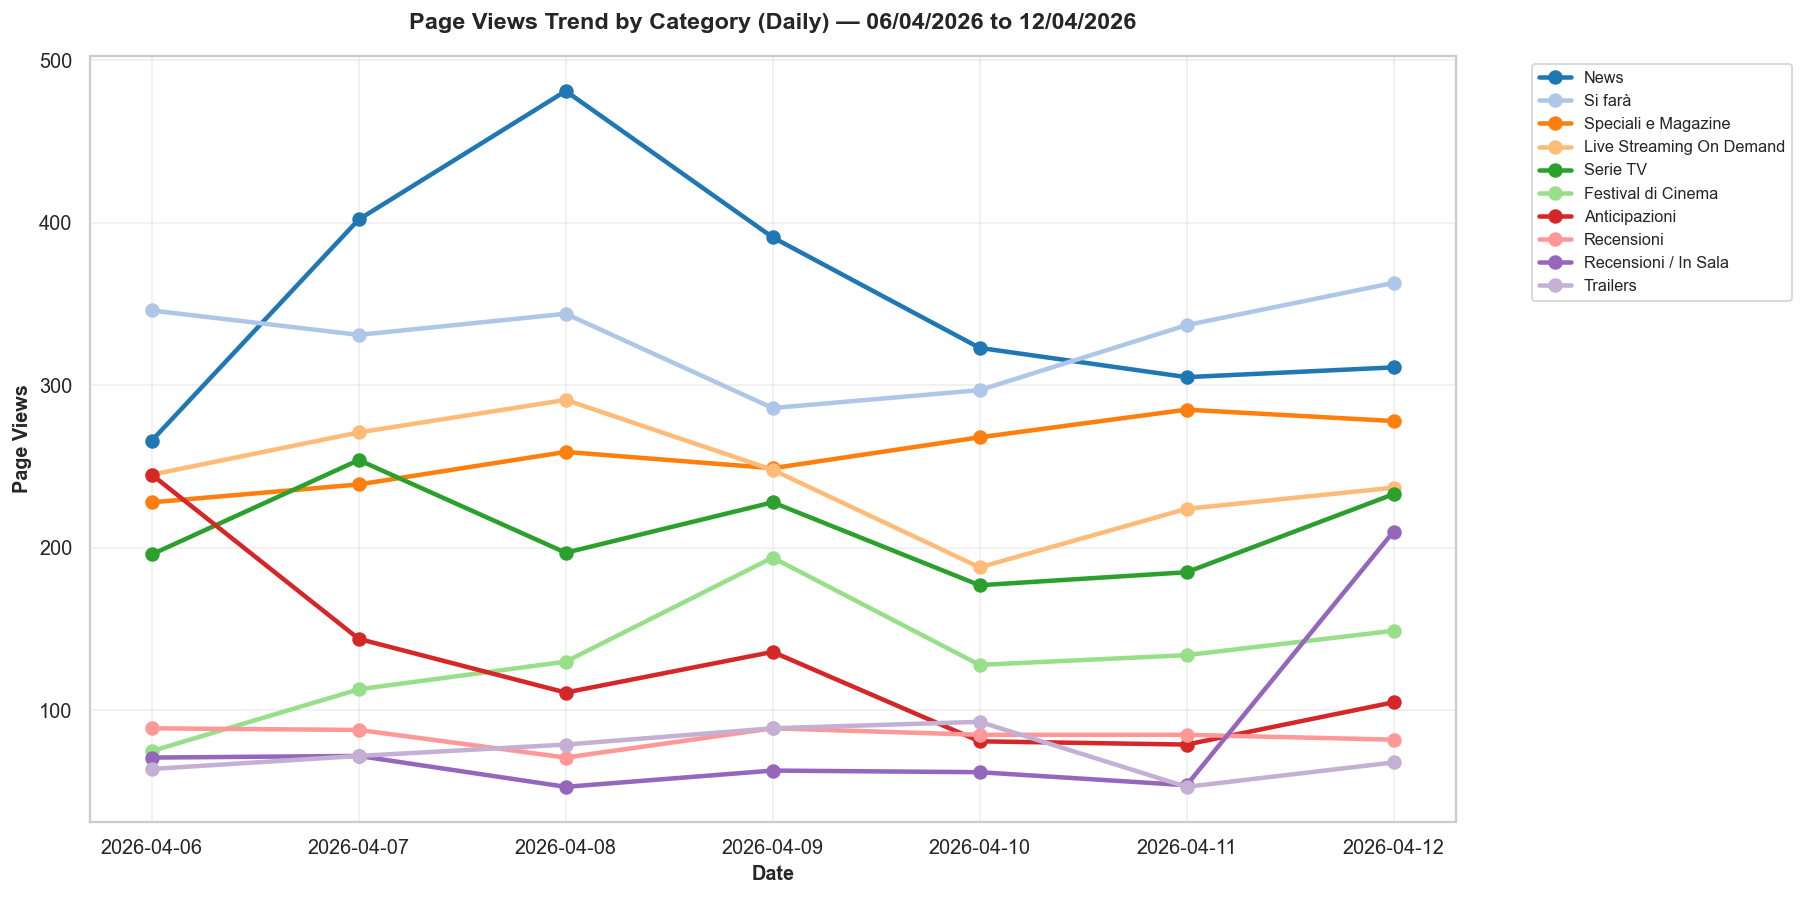


✓ Top 10 categories visualized


In [21]:
sns.set_theme(style="whitegrid", palette="tab20")
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

# Get top 10 categories by total page views
top_categories = agg_df.groupby('category')['screenPageViews'].sum().nlargest(10).index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))

for category in top_categories:
    category_data = agg_df[agg_df['category'] == category].sort_values('date_parsed')
    ax.plot(category_data['date_parsed'], category_data['screenPageViews'], 
            marker='o', label=category, linewidth=2.5, markersize=7)

ax.set_xlabel(f'{time_label}', fontweight='bold', fontsize=11)
ax.set_ylabel('Page Views', fontweight='bold', fontsize=11)
ax.set_title(f'Page Views Trend by Category ({GRANULARITY}) — {START_DATE.strftime("%d/%m/%Y")} to {END_DATE.strftime("%d/%m/%Y")}',
             fontweight='bold', fontsize=13, pad=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Top 10 categories visualized")

## Visualization 2: Engagement Rate by Category

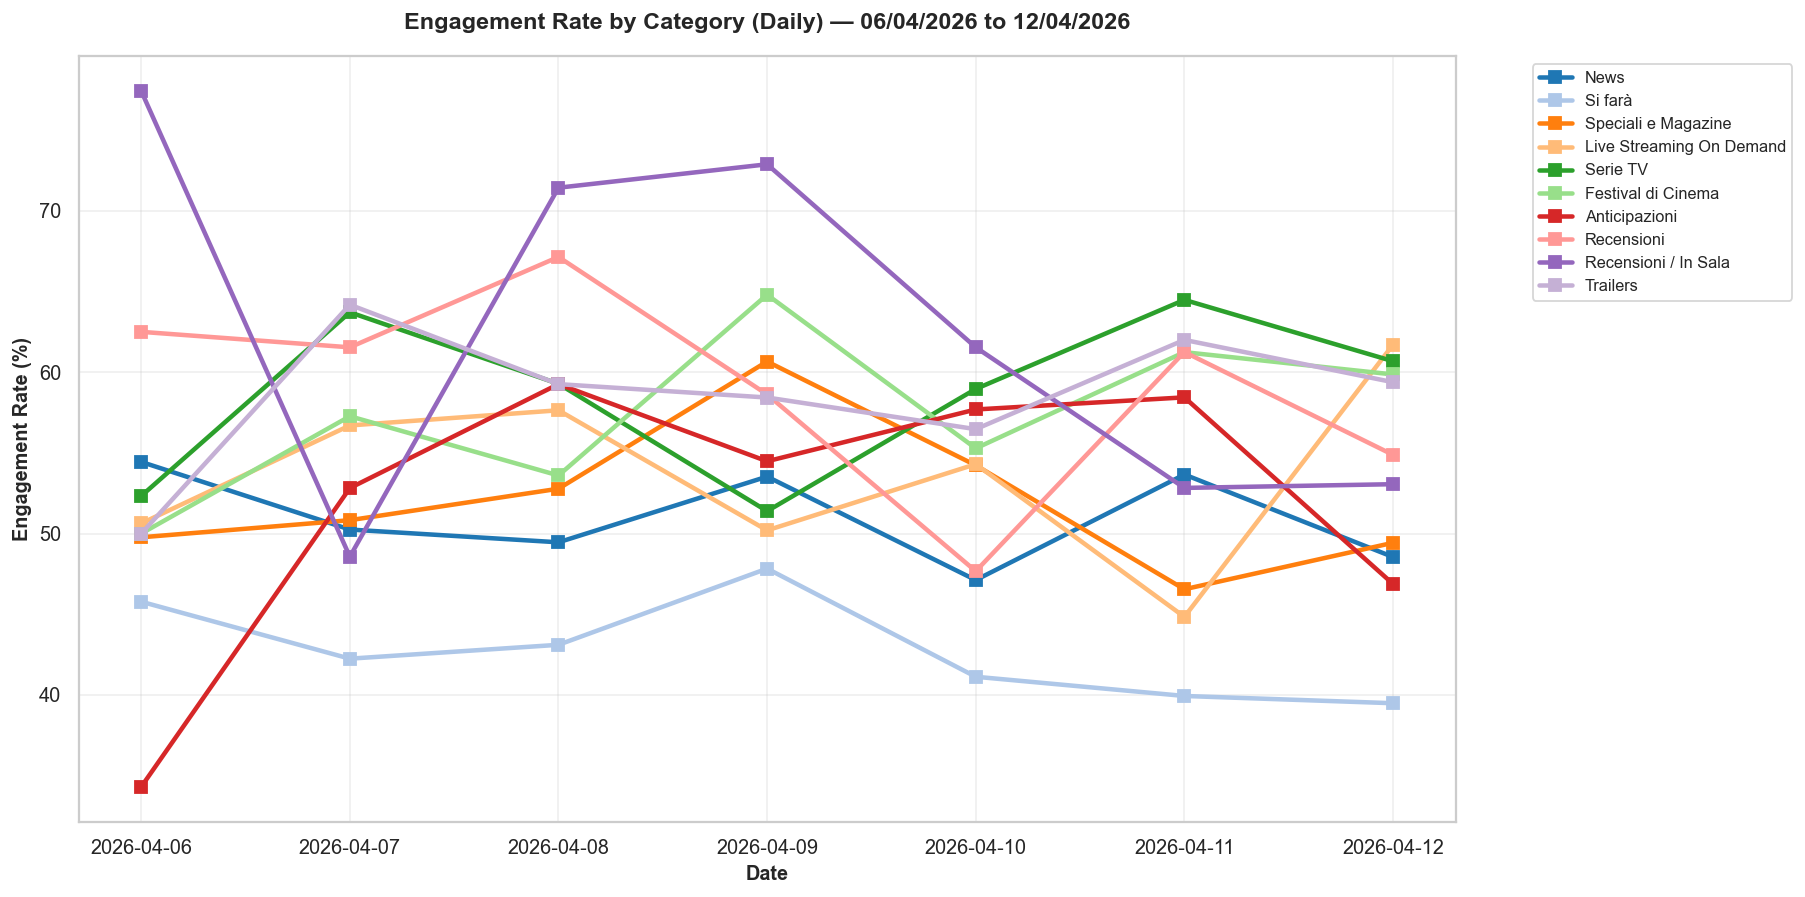


✓ Engagement rate visualization completed


In [22]:
fig, ax = plt.subplots(figsize=(14, 7))

for category in top_categories:
    category_data = agg_df[agg_df['category'] == category].sort_values('date_parsed')
    ax.plot(category_data['date_parsed'], category_data['engagementRate'], 
            marker='s', label=category, linewidth=2.5, markersize=7)

ax.set_xlabel(f'{time_label}', fontweight='bold', fontsize=11)
ax.set_ylabel('Engagement Rate (%)', fontweight='bold', fontsize=11)
ax.set_title(f'Engagement Rate by Category ({GRANULARITY}) — {START_DATE.strftime("%d/%m/%Y")} to {END_DATE.strftime("%d/%m/%Y")}',
             fontweight='bold', fontsize=13, pad=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Engagement rate visualization completed")

## Visualization 3: Heatmap — Page Views by Category & Date

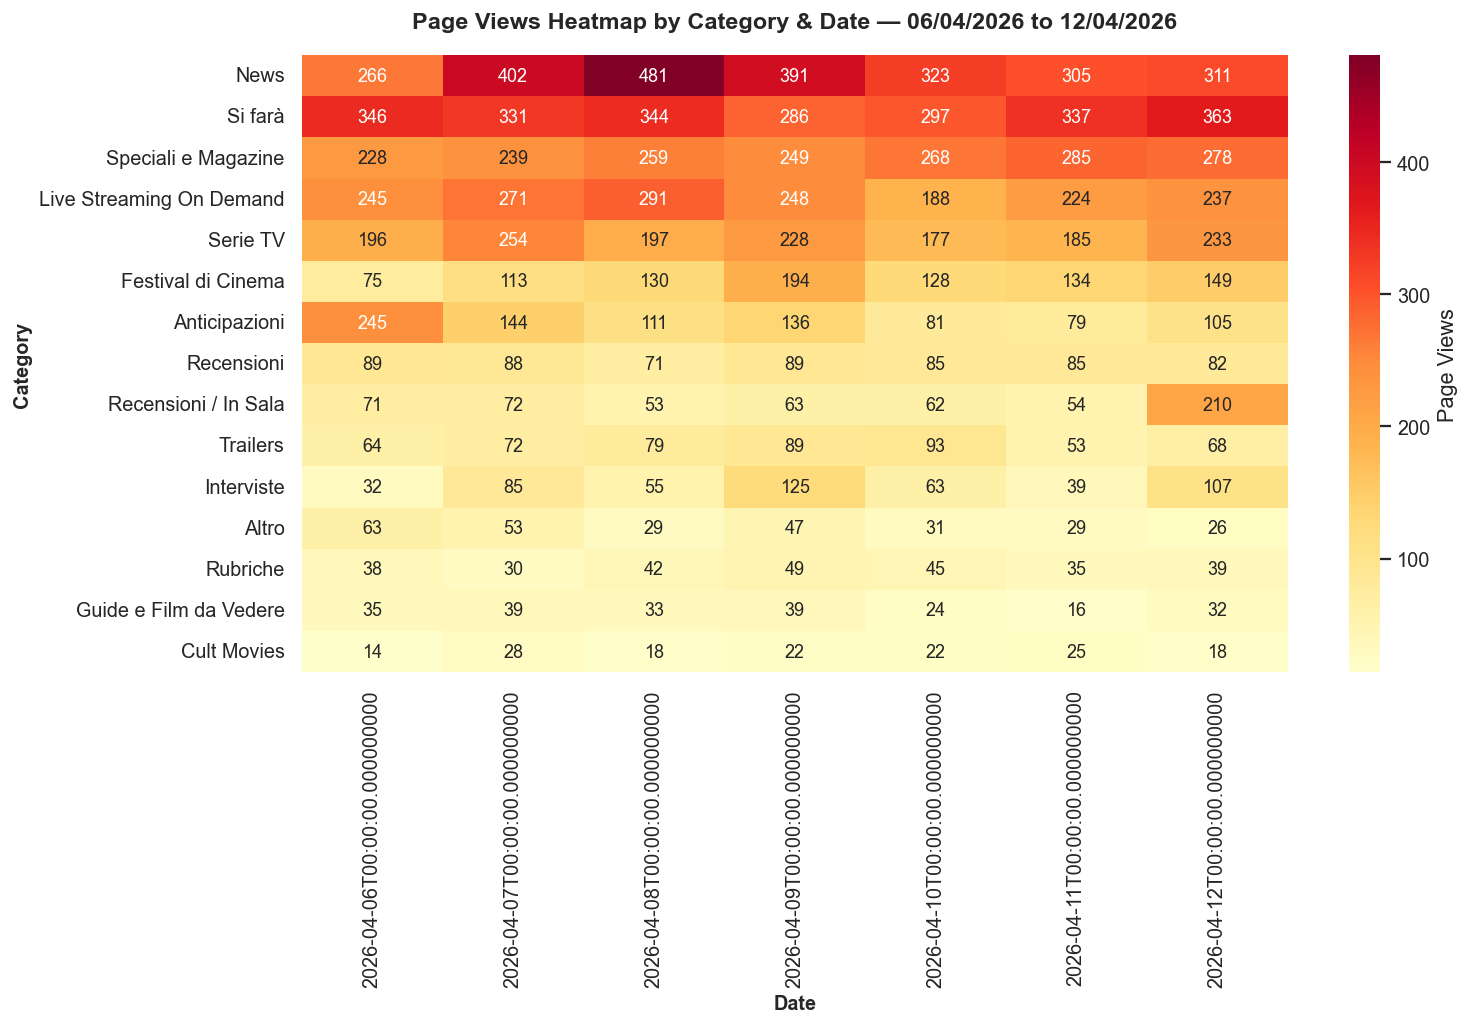


✓ Heatmap visualization completed


In [23]:
# Pivot per heatmap
pivot_pv = agg_df.pivot_table(
    index='category',
    columns='date_parsed',
    values='screenPageViews',
    aggfunc='sum'
)

# Keep only top 15 categories
top_15 = agg_df.groupby('category')['screenPageViews'].sum().nlargest(15).index.tolist()
pivot_pv = pivot_pv.loc[top_15]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_pv, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Page Views'}, ax=ax)
ax.set_title(f'Page Views Heatmap by Category & {time_label} — {START_DATE.strftime("%d/%m/%Y")} to {END_DATE.strftime("%d/%m/%Y")}',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel(f'{time_label}', fontweight='bold', fontsize=11)
ax.set_ylabel('Category', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n✓ Heatmap visualization completed")

## Top Articles by Category

In [24]:
print("\n⭐ TOP ARTICLES BY CATEGORY")
print(f"{'='*70}\n")

# Top 5 categories
for idx, category in enumerate(top_categories[:5], 1):
    print(f"\n{idx}. {category.upper()}")
    print("-" * 70)
    
    top_articles = df[df['category'] == category].groupby('pagePath').agg({
        'screenPageViews': 'sum',
        'activeUsers': 'sum',
        'averageSessionDuration': 'mean',
        'engagedSessions': 'sum'
    }).sort_values('screenPageViews', ascending=False).head(5)
    
    for article_idx, (path, row) in enumerate(top_articles.iterrows(), 1):
        # Clean up path display
        display_path = path.replace('/it/', '').replace('/', ' › ')[:70]
        print(f"   {article_idx}. {display_path}")
        print(f"      Views: {int(row['screenPageViews']):,} | Users: {int(row['activeUsers']):,} | Duration: {row['averageSessionDuration']:.1f}s")


⭐ TOP ARTICLES BY CATEGORY


1. NEWS
----------------------------------------------------------------------
   1.  › 524968 › latest-news › the-pitt-3-la-serie-hbo-max-rivela-un-addio-
      Views: 125 | Users: 117 | Duration: 52.6s
   2.  › 524880 › latest-news › kennedy.html
      Views: 93 | Users: 83 | Duration: 37.4s
   3.  › 525233 › latest-news › trust-me-il-falso-profeta.html
      Views: 78 | Users: 72 | Duration: 89.1s
   4.  › 86560 › latest-news › 5-attrici-famose-facevano-le-pornostar.html
      Views: 69 | Users: 66 | Duration: 66.1s
   5.  › 525505 › latest-news › dark-winds-5-si-fara.html
      Views: 54 | Users: 44 | Duration: 77.1s

2. SI FARÀ
----------------------------------------------------------------------
   1.  › 524355 › latest-news › si-fara › detective-hole-2-il-futuro-della-s
      Views: 223 | Users: 205 | Duration: 83.0s
   2.  › 519469 › latest-news › si-fara › the-rookie-ottava-stagione.html
      Views: 185 | Users: 150 | Duration: 43.2s
   3.  › 51

## Session Performance Analysis

In [25]:
print("\n📊 SESSION PERFORMANCE ANALYSIS")
print(f"{'='*70}\n")

# Total sessions by category
sessions_by_cat = agg_df.groupby('category').agg({
    'sessions': 'sum',
    'engagedSessions': 'sum',
    'screenPageViews': 'sum',
    'activeUsers': 'sum',
    'averageSessionDuration': 'mean'
}).round(2)

sessions_by_cat['engagementRate'] = (sessions_by_cat['engagedSessions'] / sessions_by_cat['sessions'] * 100).round(2)
sessions_by_cat['viewsPerSession'] = (sessions_by_cat['screenPageViews'] / sessions_by_cat['sessions']).round(2)
sessions_by_cat = sessions_by_cat.sort_values('screenPageViews', ascending=False).head(15)

print(sessions_by_cat)


📊 SESSION PERFORMANCE ANALYSIS

                          sessions  engagedSessions  screenPageViews  \
category                                                               
News                          2394             1217             2479   
Si farà                       2238              955             2304   
Speciali e Magazine           1757              913             1806   
Live Streaming On Demand      1675              903             1704   
Serie TV                      1441              847             1470   
Festival di Cinema             884              516              923   
Anticipazioni                  874              429              901   
Recensioni                     571              336              589   
Recensioni / In Sala           554              332              585   
Trailers                       498              291              518   
Interviste                     483              234              506   
Altro                          

## Summary Report

In [26]:
print("\n✅ ANALYSIS COMPLETE")
print(f"{'='*70}")
print(f"📅 Period analyzed: {START_DATE.strftime('%d/%m/%Y')} → {END_DATE.strftime('%d/%m/%Y')} ({(END_DATE - START_DATE).days + 1} days)")
print(f"📊 Categories analyzed: {agg_df['category'].nunique()}")
print(f"📈 Total Page Views: {agg_df['screenPageViews'].sum():,.0f}")
print(f"👥 Total Active Users: {agg_df['activeUsers'].sum():,.0f}")
print(f"💬 Average Engagement Rate: {agg_df['engagementRate'].mean():.2f}%")
print(f"⏱  Average Session Duration: {agg_df['averageSessionDuration'].mean():.1f}s")
print(f"\n💡 Data is ready for further insights and decision-making!")


✅ ANALYSIS COMPLETE
📅 Period analyzed: 06/04/2026 → 12/04/2026 (7 days)
📊 Categories analyzed: 16
📈 Total Page Views: 14,729
👥 Total Active Users: 12,677
💬 Average Engagement Rate: 51.93%
⏱  Average Session Duration: 90.0s

💡 Data is ready for further insights and decision-making!
